In [342]:
from LabData.DataLoaders.BodyMeasuresLoader import BodyMeasuresLoader
from LabData.DataLoaders.ItamarSleepLoader import ItamarSleepLoader
from LabData.DataLoaders.BloodTestsLoader import BloodTestsLoader
from LabData.DataLoaders.DEXALoader import DEXALoader
from LabData.DataLoaders.UltrasoundLoader import UltrasoundLoader
from LabData.DataLoaders.GutMBLoader import GutMBLoader
from LabData.DataLoaders.SubjectLoader import SubjectLoader
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
from collections import defaultdict

plt.style.use('default')              
sns.set_theme(style='whitegrid')      

Process dexa, ultrasound and sleep phenotypes

In [343]:
dexa = DEXALoader().get_data(study_ids=[10])
ultrasound = UltrasoundLoader().get_data(study_ids=[10])
sleep = ItamarSleepLoader().get_data(study_ids=[10])

[]


In [344]:
dexa_df = dexa.df.reset_index()
dexa_df_meta = dexa.df_metadata.reset_index()

ultrasound_df = ultrasound.df.reset_index()
ultrasound_df_meta = ultrasound.df_metadata.reset_index()

sleep_df = sleep.df.reset_index()
sleep_df_meta = sleep.df_metadata.reset_index()

In [345]:
dexa_df.columns.to_list()

['RegistrationCode',
 'Date',
 'body_comp_trunk_diff_fat_mass',
 'spine_l2_l3_am_percent',
 'femur_left_total_area',
 'body_comp_leg_right_tissue_mass',
 'body_comp_trunk_left_lean_mass',
 'total_scan_sat_volume',
 'spine_l2_ya_percent',
 'femur_wards_mean_am_percent',
 'body_arm_right_bmd',
 'femur_total_mean_z_score',
 'body_ribs_bmd',
 'body_trunk_right_bmc',
 'femur_neck_mean_am_percent',
 'femur_shaft_mean_bmd',
 'femur_right_wards_bmc',
 'body_trunk_right_bmd',
 'body_head_area',
 'body_comp_trunk_left_tissue_mass',
 'body_spine_bmc',
 'femur_upper_neck_mean_ya_percent',
 'femur_left_neck_t_score',
 'spine_l1_l4_z_score',
 'body_comp_legs_region_percent_fat',
 'femur_left_total_ya_percent',
 'spine_l1_l2_bmc',
 'femur_left_troch_bmd',
 'body_total_left_bmc',
 'femur_neck_mean_z_score',
 'spine_l1_l3_area',
 'femur_left_troch_bmc',
 'femur_left_upper_neck_t_score',
 'femur_right_neck_am_percent',
 'spine_l4_average_height',
 'body_comp_legs_diff_bone_mass',
 'spine_l1_l4_t_score',

In [346]:
ultrasound = pd.merge(ultrasound_df, ultrasound_df_meta, on=['RegistrationCode', 'Date'], how='outer')
ultrasound_baseline = ultrasound[ultrasound['research_stage'] == 'baseline']
ultrasound_baseline = ultrasound_baseline.drop_duplicates(subset='RegistrationCode', keep='first')

if 'gender' in ultrasound_baseline.columns:
    # Rename to sex
    ultrasound_baseline.rename(columns={'gender': 'sex'}, inplace=True)

ultrasound_baseline

dexa = pd.merge(dexa_df, dexa_df_meta, on=['RegistrationCode', 'Date'], how='outer')
dexa_baseline = dexa[dexa['research_stage'] == 'baseline']
dexa_baseline = dexa_baseline.drop_duplicates(subset='RegistrationCode', keep='first')

if 'gender' in dexa_baseline.columns:
    # Rename to sex
    dexa_baseline.rename(columns={'gender': 'sex'}, inplace=True)

dexa_baseline

sleep = pd.merge(sleep_df, sleep_df_meta, on=['RegistrationCode', 'Date'], how='outer')
sleep_baseline = sleep[sleep['research_stage'] == 'baseline'].copy()
# Average features for all 3 nights

if 'gender' in sleep_baseline.columns:
    # Rename to sex
    sleep_baseline.rename(columns={'gender': 'sex'}, inplace=True)

sleep_baseline = sleep_baseline.groupby('RegistrationCode', as_index=False).agg({
    'age': 'first',         
    'sex': 'first',      
    'AHI': 'mean',
    'ODI': 'mean',
    'RDI': 'mean'
})
sleep_baseline = sleep_baseline.drop_duplicates(subset='RegistrationCode', keep='first')
sleep_baseline

,RegistrationCode,age,sex,AHI,ODI,RDI
0,10K_1000942861,54.0,1.0,17.575000,6.870000,25.930000
1,10K_1001201093,21.0,0.0,0.930000,0.183333,11.483333
2,10K_1002033709,43.0,0.0,3.696000,1.110000,14.128000
3,10K_1002254441,45.0,1.0,5.503333,2.330000,10.346667
4,10K_1003113258,49.0,1.0,1.920000,0.520000,6.820000
...,...,...,...,...,...,...
6801,10K_9994795317,47.0,1.0,15.116667,10.683333,19.480000
6802,10K_9995623290,54.0,1.0,5.113333,2.566667,12.683333
6803,10K_9995823183,47.0,1.0,4.516667,0.370000,23.946667
6804,10K_9996884777,53.0,0.0,NaN,NaN,NaN


Process body measurements

In [347]:
bm = BodyMeasuresLoader().get_data(study_ids=[10])
bm_df = bm.df.reset_index()
bm_df_meta = bm.df_metadata.reset_index()

In [348]:
bm_df.columns.to_list()

['RegistrationCode',
 'Date',
 'frequency_of_period',
 'weight',
 'lying_blood_pressure_pulse_rate',
 'on_hormone_therapy',
 'body_fat',
 'number_of_days_in_cycle',
 'standing_one_min_blood_pressure_systolic',
 'is_getting_period',
 'standing_one_min_blood_pressure_diastolic',
 'abdominal',
 'standing_one_min_blood_pressure_pulse_rate',
 'body_temperature',
 'lying_blood_pressure_diastolic',
 'hand_grip_right',
 'bmi',
 'standing_three_min_blood_pressure_pulse_rate',
 'waist',
 'sitting_blood_pressure_systolic',
 'dizziness',
 'standing_three_min_blood_pressure_systolic',
 'trunk_fat',
 'bmr',
 'number_of_days_from_last_period',
 'neck_circumference',
 'fingers_grip_left',
 'standing_three_min_blood_pressure_diastolic',
 'hand_grip_left',
 'height',
 'fingers_grip_right',
 'sitting_blood_pressure_diastolic',
 'sitting_blood_pressure_pulse_rate',
 'hips',
 'lying_blood_pressure_systolic',
 'dominant_hand',
 'whr']

In [349]:
bm_df_meta

,RegistrationCode,Date,sitting_another_hand_blood_pressure_pulse_rate,StudyTypeID8,yob,city,second_hand_grip_right,source_created_at,country,month_of_birth,...,sitting_second_blood_pressure_pulse_rate,StudyTypeID2,blood_pressure_letter_to_physician,research_stage,sitting_second_blood_pressure_diastolic,gender,second_hand_grip_left,blood_pressure_hand,sitting_second_blood_pressure_systolic,us_state
0,10K_1000942861,2021-12-13 07:09:38.954985,NaN,NaN,1967.0,רחובות,NaN,2021-12-13 07:09:38.954985+00:00,IL,8.0,...,NaN,NaN,NaN,baseline,NaN,1.0,NaN,NaN,NaN,None
1,10K_1001201093,2021-08-26 07:39:21.411519,NaN,NaN,1979.0,ראשון לציון,NaN,2021-08-26 07:39:21.411519+00:00,IL,8.0,...,NaN,NaN,NaN,baseline,NaN,0.0,NaN,NaN,NaN,None
2,10K_1001201093,2023-09-12 10:23:05.534125,73.0,NaN,1979.0,ראשון לציון,75.0,2023-09-12 10:23:05.534125+00:00,IL,8.0,...,74.0,NaN,Not Given,02_00_visit,57.0,0.0,65.0,Left,107.0,None
3,10K_1001201093,2025-10-28 06:12:29.364442,63.0,NaN,1979.0,ראשון לציון,78.1,2025-10-28 06:12:29.364442+00:00,IL,8.0,...,71.0,NaN,Not Given,04_00_visit,63.0,0.0,72.2,Left,100.0,None
4,10K_1002033709,2022-08-03 07:20:01.044769,NaN,NaN,1979.0,תל אביב-יפו,NaN,2022-08-03 07:20:01.044769+00:00,IL,10.0,...,69.0,NaN,Not Given,baseline,74.0,0.0,NaN,Left,100.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23250,10K_9998635752,2024-04-08 06:49:26.293372,54.0,NaN,1964.0,None,113.9,2024-04-08 06:49:26.293372+00:00,IL,12.0,...,55.0,NaN,Not Given,baseline,71.0,1.0,99.4,Left,117.0,None
23251,10K_9999226141,2020-01-21 08:54:23.012570,NaN,NaN,1978.0,בני ראם,NaN,2020-01-21 08:54:23.012570+00:00,IL,7.0,...,NaN,NaN,NaN,baseline,NaN,1.0,NaN,NaN,NaN,None
23252,10K_9999226141,2022-10-03 10:35:41.162233,NaN,NaN,1978.0,בני ראם,NaN,2022-10-03 10:35:41.162233+00:00,IL,7.0,...,85.0,NaN,Not Given,02_00_visit,96.0,1.0,NaN,Left,134.0,None
23253,10K_9999226141,2024-01-14 11:39:01.990983,61.0,NaN,1978.0,בני ראם,131.0,2024-01-14 11:39:01.990983+00:00,IL,7.0,...,65.0,NaN,Not Given,04_00_visit,66.0,1.0,118.0,Left,119.0,None


In [350]:
bm = pd.merge(bm_df, bm_df_meta, on=['RegistrationCode', 'Date'], how='outer')
bm['waist_height_ratio'] = bm['waist'] / bm['height']
bm = bm.rename(columns={'whr': 'waist_hips_ratio'})
bm_baseline = bm[bm['research_stage'] == 'baseline'].copy()

if 'gender' in bm_baseline.columns:
    # Rename to sex
    bm_baseline.rename(columns={'gender': 'sex'}, inplace=True)

bm_baseline

,RegistrationCode,Date,frequency_of_period,weight,lying_blood_pressure_pulse_rate,on_hormone_therapy,body_fat,number_of_days_in_cycle,standing_one_min_blood_pressure_systolic,is_getting_period,...,StudyTypeID2,blood_pressure_letter_to_physician,research_stage,sitting_second_blood_pressure_diastolic,sex,second_hand_grip_left,blood_pressure_hand,sitting_second_blood_pressure_systolic,us_state,waist_height_ratio
0,10K_1000942861,2021-12-13 07:09:38.954985,NaN,91.800003,50.0,NaN,NaN,NaN,145.0,NaN,...,NaN,NaN,baseline,NaN,1.0,NaN,NaN,NaN,None,0.548476
1,10K_1001201093,2021-08-26 07:39:21.411519,NaN,59.400002,66.0,NaN,NaN,NaN,103.0,NaN,...,NaN,NaN,baseline,NaN,0.0,NaN,NaN,NaN,None,0.447059
4,10K_1002033709,2022-08-03 07:20:01.044769,NaN,55.000000,60.0,NaN,NaN,NaN,102.0,NaN,...,NaN,Not Given,baseline,74.0,0.0,NaN,Left,100.0,None,0.503145
5,10K_1002087123,2019-12-04 11:53:40.350115,NaN,105.699997,72.0,NaN,45.099998,27.0,135.0,Yes,...,NaN,NaN,baseline,NaN,0.0,NaN,NaN,NaN,None,0.665489
7,10K_1002254441,2022-09-15 07:00:31.408388,NaN,74.000000,66.0,NaN,NaN,NaN,114.0,NaN,...,NaN,Not Given,baseline,72.0,1.0,NaN,Left,103.0,None,0.505618
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23248,10K_9998418497,2019-11-07 12:22:35.407303,NaN,66.000000,71.0,NaN,32.200001,28.0,86.0,Yes,...,NaN,NaN,baseline,NaN,0.0,NaN,NaN,NaN,None,0.516934
23249,10K_9998420917,2023-07-23 10:17:17.205009,NaN,56.200001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Not Given,baseline,63.0,0.0,68.1,Left,100.0,None,0.413580
23250,10K_9998635752,2024-04-08 06:49:26.293372,NaN,67.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Not Given,baseline,71.0,1.0,99.4,Left,117.0,None,0.468208
23251,10K_9999226141,2020-01-21 08:54:23.012570,NaN,78.900002,61.0,NaN,16.700001,NaN,129.0,NaN,...,NaN,NaN,baseline,NaN,1.0,NaN,NaN,NaN,None,0.486034


Load gut microbiome data

In [351]:
subjects_dl = SubjectLoader()
subjects_data = subjects_dl.get_data(groupby_reg='first', study_ids=[10])
subjects_df = subjects_data.df.copy()

gut_bacteria = GutMBLoader().get_data('segal_species', subjects_df=subjects_df, study_ids=[10], research_stage='baseline',
                            groupby_reg='first', genotek_vals=[1],
                            min_col_present_frac=0.05, min_col_val=1e-4, take_log=True)

gut_bacteria_df = gut_bacteria.df.copy()
gut_bacteria_df_meta = gut_bacteria.df_metadata.copy()

gut_bacteria_df = gut_bacteria_df.join(gut_bacteria_df_meta[['age', 'gender', 'RegistrationCode', 'Date']]).copy()
gut_bacteria_df = gut_bacteria_df[
    list(gut_bacteria_df.columns[-2:]) + list(gut_bacteria_df.columns[:-2])
].copy()

gut_bacteria_df = gut_bacteria_df.reset_index(drop=True)
gut_bacteria_df = gut_bacteria_df.rename(columns={'Date': 'microbiome_date', 'gender': 'sex'})
gut_bacteria_df

/home/barakdan/.local/lib/python3.7/site-packages/pandas/core/frame.py:6402: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  key,


,RegistrationCode,microbiome_date,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,age,sex
0,10K_4510122421,2019-05-29 08:25:00,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-2.868946,-2.581231,48.0,0.0
1,10K_9304809174,2019-04-22 10:22:03,-4.0,-4.0,-1.772241,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-3.315908,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,59.0,1.0
2,10K_8273374731,2020-04-30 16:22:01,-4.0,-4.0,-1.770738,-3.041183,-4.0,-4.0,-2.783096,-4.000000,...,-4.000000,-2.939253,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,45.0,1.0
3,10K_2302377468,2019-04-22 10:23:55,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-2.599674,-4.000000,-4.000000,-4.0,-4.0,-3.786285,-4.000000,-4.000000,49.0,0.0
4,10K_4972103700,2019-05-06 09:27:44,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-2.524367,-2.859949,-4.000000,50.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11014,10K_5914111457,2025-06-17 07:18:56,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-3.134390,-4.0,-4.0,-4.000000,-2.209011,-4.000000,54.0,0.0
11015,10K_8248030182,2025-08-07 11:26:10,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-2.822961,-4.000000,-4.0,-4.0,-4.000000,-2.851225,-2.159856,49.0,0.0
11016,10K_3710482944,2025-08-27 12:07:08,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-2.286574,-2.045412,...,-3.644700,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-3.025499,49.0,1.0
11017,10K_8256809791,2025-06-17 07:21:58,-4.0,-4.0,-4.000000,-1.998214,-4.0,-4.0,-4.000000,-4.000000,...,-3.037901,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,55.0,0.0


Map genome bins into readable species names

In [352]:
mb_names = pd.read_pickle("/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/mb_names.pkl")
mb_names.head()

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new,Daniel_Species
fBin__14|gBin__27|sBin__33,Rep_33,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp000438015,33.0,27.0,...,6132,2164,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia sp000438015,Merdousia sp000438015
fBin__14|gBin__34|sBin__41,Rep_41,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp900545715,41.0,34.0,...,6123,2163,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia gallistercoris,Merdousia gallistercoris
fBin__14|gBin__34|sBin__42,Rep_42,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp900545705,42.0,34.0,...,6123,2163,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia sp900545705,Merdousia sp900545705
fBin__17|gBin__39|sBin__51,Rep_51,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,RC9,RC9 sp000433355,51.0,39.0,...,1627,658,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp000433355,Cryptobacteroides sp000433355
fBin__27|gBin__64|sBin__81,Rep_81,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter splanchnicus,81.0,64.0,...,1333,589,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter splanchnicus,Odoribacter splanchnicus


In [353]:
mb_names[mb_names['species_new'] == 'Otoolea fessa']

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new,Daniel_Species
fBin__357|gBin__1401|sBin__2077,Rep_2077,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Clostridium_Q,Clostridium_Q sp003024715,2077.0,1401.0,...,3525,1439,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Otoolea,Otoolea fessa,Otoolea fessa


In [354]:
gut_bacteria_df

,RegistrationCode,microbiome_date,fBin__100|gBin__473|sBin__693,fBin__100|gBin__473|sBin__694,fBin__100|gBin__474|sBin__695,fBin__100|gBin__477|sBin__698,fBin__100|gBin__481|sBin__704,fBin__100|gBin__481|sBin__705,fBin__100|gBin__481|sBin__706,fBin__100|gBin__483|sBin__709,...,fBin__88|gBin__434|sBin__637,fBin__94|gBin__448|sBin__654,fBin__94|gBin__449|sBin__656,fBin__95|gBin__450|sBin__659,fBin__96|gBin__457|sBin__669,fBin__97|gBin__462|sBin__676,fBin__97|gBin__462|sBin__678,fBin__99|gBin__469|sBin__687,age,sex
0,10K_4510122421,2019-05-29 08:25:00,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-2.868946,-2.581231,48.0,0.0
1,10K_9304809174,2019-04-22 10:22:03,-4.0,-4.0,-1.772241,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-3.315908,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,59.0,1.0
2,10K_8273374731,2020-04-30 16:22:01,-4.0,-4.0,-1.770738,-3.041183,-4.0,-4.0,-2.783096,-4.000000,...,-4.000000,-2.939253,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,45.0,1.0
3,10K_2302377468,2019-04-22 10:23:55,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-2.599674,-4.000000,-4.000000,-4.0,-4.0,-3.786285,-4.000000,-4.000000,49.0,0.0
4,10K_4972103700,2019-05-06 09:27:44,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-2.524367,-2.859949,-4.000000,50.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11014,10K_5914111457,2025-06-17 07:18:56,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-3.134390,-4.0,-4.0,-4.000000,-2.209011,-4.000000,54.0,0.0
11015,10K_8248030182,2025-08-07 11:26:10,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-2.822961,-4.000000,-4.0,-4.0,-4.000000,-2.851225,-2.159856,49.0,0.0
11016,10K_3710482944,2025-08-27 12:07:08,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-2.286574,-2.045412,...,-3.644700,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-3.025499,49.0,1.0
11017,10K_8256809791,2025-06-17 07:21:58,-4.0,-4.0,-4.000000,-1.998214,-4.0,-4.0,-4.000000,-4.000000,...,-3.037901,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,55.0,0.0


In [355]:
def rename_microbiome_columns(df: pd.DataFrame, mb_names: pd.DataFrame):
    """
    Rename microbiome columns using mb_names, deduplicate with suffixes,
    and return both the modified DataFrame and the final mapping as a DataFrame.
    First occurrence keeps base name, duplicates get _1, _2, etc.
    Excludes metadata rows from the mapping.
    """
    # --- Normalize ---
    mb_names.index = mb_names.index.str.strip()
    df = df.copy()
    df.columns = df.columns.str.strip()

    # --- Extract maps ---
    species_map = mb_names['species_new'].str.strip()
    genus_map = mb_names['genus_new'].str.strip()
    family_map = mb_names['family_new'].str.strip()

    # --- Build preliminary name mapping ---
    preliminary_mapping = {}
    for col in df.columns[1:]:  # Skip first identifier column
        name = species_map.get(col, None)
        if name == "unknown" or pd.isna(name):
            name = genus_map.get(col, None)
        if name == "unknown" or pd.isna(name):
            name = family_map.get(col, None)
        if name is None or name == "unknown":
            name = col  # fallback
        preliminary_mapping[col] = name

    # --- Apply initial rename ---
    df.rename(columns=preliminary_mapping, inplace=True)

    # --- Deduplicate with suffixes ---
    name_counter = defaultdict(int)
    final_mapping = {}
    new_cols = []

    # Keep first identifier column unchanged
    new_cols.append(df.columns[0])

    for old_col, base_name in preliminary_mapping.items():
        name_counter[base_name] += 1
        if name_counter[base_name] == 1:
            deduped_name = base_name
        else:
            deduped_name = f"{base_name}_{name_counter[base_name]-1}"
        final_mapping[old_col] = deduped_name
        new_cols.append(deduped_name)

    df.columns = new_cols

    # --- Convert final_mapping to DataFrame ---
    mapping_df = pd.DataFrame(
        list(final_mapping.items()), 
        columns=["Original", "Daniel_Species"]
    )

    # --- Drop metadata rows if present ---
    exclude = {"microbiome_date", "age", "gender"}
    mapping_df = mapping_df[~mapping_df["Original"].isin(exclude)]

    return df, mapping_df

gut_bacteria_df, final_mapping_df = rename_microbiome_columns(gut_bacteria_df, mb_names)
gut_bacteria_df

,RegistrationCode,microbiome_date,Duodenibacillus intestinigallinarum,Duodenibacillus intestinavium,Duodenibacillus massiliensis,Sutterella wadsworthensis,Sutterella sp937923675,Sutterella seckii_A,Sutterella sp934255515,Sutterella wadsworthensis_A,...,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis,age,sex
0,10K_4510122421,2019-05-29 08:25:00,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-2.868946,-2.581231,48.0,0.0
1,10K_9304809174,2019-04-22 10:22:03,-4.0,-4.0,-1.772241,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-3.315908,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,59.0,1.0
2,10K_8273374731,2020-04-30 16:22:01,-4.0,-4.0,-1.770738,-3.041183,-4.0,-4.0,-2.783096,-4.000000,...,-4.000000,-2.939253,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,45.0,1.0
3,10K_2302377468,2019-04-22 10:23:55,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-2.599674,-4.000000,-4.000000,-4.0,-4.0,-3.786285,-4.000000,-4.000000,49.0,0.0
4,10K_4972103700,2019-05-06 09:27:44,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-2.524367,-2.859949,-4.000000,50.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11014,10K_5914111457,2025-06-17 07:18:56,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-4.000000,-3.134390,-4.0,-4.0,-4.000000,-2.209011,-4.000000,54.0,0.0
11015,10K_8248030182,2025-08-07 11:26:10,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,...,-4.000000,-2.822961,-4.000000,-4.0,-4.0,-4.000000,-2.851225,-2.159856,49.0,0.0
11016,10K_3710482944,2025-08-27 12:07:08,-4.0,-4.0,-4.000000,-4.000000,-4.0,-4.0,-2.286574,-2.045412,...,-3.644700,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-3.025499,49.0,1.0
11017,10K_8256809791,2025-06-17 07:21:58,-4.0,-4.0,-4.000000,-1.998214,-4.0,-4.0,-4.000000,-4.000000,...,-3.037901,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,55.0,0.0


In [356]:
final_mapping_df

,Original,Daniel_Species
1,fBin__100|gBin__473|sBin__693,Duodenibacillus intestinigallinarum
2,fBin__100|gBin__473|sBin__694,Duodenibacillus intestinavium
3,fBin__100|gBin__474|sBin__695,Duodenibacillus massiliensis
4,fBin__100|gBin__477|sBin__698,Sutterella wadsworthensis
5,fBin__100|gBin__481|sBin__704,Sutterella sp937923675
...,...,...
722,fBin__96|gBin__457|sBin__669,Aphodousia faecalis
723,fBin__97|gBin__462|sBin__676,Parasutterella gallistercoris
724,fBin__97|gBin__462|sBin__678,Parasutterella excrementihominis
725,fBin__99|gBin__469|sBin__687,Mesosutterella multiformis


In [357]:
# Ensure Original is used as index for alignment
final_mapping_indexed = final_mapping_df.set_index("Original")

# Add Renamed column to mb_names, aligned by index
mb_names = mb_names.copy()
mb_names["Daniel_Species"] = mb_names.index.map(final_mapping_indexed["Daniel_Species"])

mb_names

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new,Daniel_Species
fBin__14|gBin__27|sBin__33,Rep_33,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp000438015,33.0,27.0,...,6132,2164,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia sp000438015,Merdousia sp000438015
fBin__14|gBin__34|sBin__41,Rep_41,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp900545715,41.0,34.0,...,6123,2163,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia gallistercoris,Merdousia gallistercoris
fBin__14|gBin__34|sBin__42,Rep_42,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,CAG-312,CAG-312 sp900545705,42.0,34.0,...,6123,2163,Bacteria,Verrucomicrobiota,Verrucomicrobiae,Opitutales,CAG-312,Merdousia,Merdousia sp900545705,Merdousia sp900545705
fBin__17|gBin__39|sBin__51,Rep_51,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,RC9,RC9 sp000433355,51.0,39.0,...,1627,658,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,UBA932,Cryptobacteroides,Cryptobacteroides sp000433355,Cryptobacteroides sp000433355
fBin__27|gBin__64|sBin__81,Rep_81,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter splanchnicus,81.0,64.0,...,1333,589,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Marinifilaceae,Odoribacter,Odoribacter splanchnicus,Odoribacter splanchnicus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fBin__619|gBin__2353|sBin__3576,Rep_3576,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,UBA737,UBA737 sp900549755,3576.0,2353.0,...,3321,1359,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Acutalibacteraceae,UBA737,UBA737 sp900549755,UBA737 sp900549755
fBin__619|gBin__2353|sBin__3578,Rep_3578,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,UBA737,unknown,3578.0,2353.0,...,3321,1359,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Acutalibacteraceae,UBA737,UBA737 sp905193585,UBA737 sp905193585
fBin__625|gBin__2361|sBin__3588,Rep_3588,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,UMGS1071,UMGS1071 sp900541905,3588.0,2361.0,...,3109,1292,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Acutalibacteraceae,UMGS1071,UMGS1071 sp900541905,UMGS1071 sp900541905
fBin__625|gBin__2361|sBin__3589,Rep_3589,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,UMGS1071,UMGS1071 sp900542375,3589.0,2361.0,...,3109,1292,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Acutalibacteraceae,UMGS1071,UMGS1071 sp900542375,UMGS1071 sp900542375


In [358]:
home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
mb_names.to_pickle(home_path +f"data/mb_names.pkl")

Process blood test phenotypes

In [359]:
blood_test_loader = BloodTestsLoader().get_data(study_ids=[10])
bt_df = blood_test_loader.df
bt_df_meta = blood_test_loader.df_metadata

bt_df['triglyceride_to_hdl_ratio'] = bt_df['bt__triglycerides'] / bt_df['bt__hdl_cholesterol']

blood_measures = pd.merge(bt_df, bt_df_meta, on=['RegistrationCode', 'Date'], how='outer')
blood_baseline = blood_measures[blood_measures['research_stage'] == 'baseline'].copy()

In [360]:
blood_baseline.columns.to_list()

['bt__leukocytes_u_field',
 'bt__immature_granulocytes',
 'bt__hemolysis_index',
 'bt__lithium',
 'bt__bilirubin_indirect',
 'bt__antinuclear_ab_adults',
 'bt__mcv',
 'bt__hiv',
 'bt__lymphocytes_abs',
 'bt__sgot',
 'bt__bilirubin_direct',
 'bt__occult_blood_screen_fecal',
 'bt__ebv_igg',
 'urine__creatinine_24',
 'urine__erythrocytes',
 'bt__lamictal_serum',
 'urine__potassium_24',
 'bt__chlamydia',
 'bt__rbc_hypo_%',
 'bt__ggt',
 'bt__hepatitis_c_ab',
 'bt__ldh',
 'urine__creatinine',
 'bt__hemoglobin_distribution_width',
 'bt__insulin',
 'bt__covid19',
 'bt__sgpt',
 'urine__sodium',
 'bt__protein_total',
 'bt__iga_deficiency',
 'bt__uric_acid',
 'bt__igm',
 'bt__pertussis_iga',
 'bt__vitamin_b12',
 'bt__anti_dgp_iga_celiac',
 'bt__eosinophils_abs',
 'bt__immunofixation',
 'bt__rdw',
 'urine__cylinder_hyaline',
 'urine__urine_culture',
 'bt__testosterone',
 'urine__phosphore_24',
 'bt__sodium',
 'bt__hba1c',
 'bt__alkaline_phosphatase',
 'bt__lymphocyte_atypical_abs',
 'bt__tumor_mar

In [361]:
blood_test_loader = BloodTestsLoader().get_data(study_ids=[10])
bt_df = blood_test_loader.df
bt_df_meta = blood_test_loader.df_metadata

bt_df['triglyceride_to_hdl_ratio'] = bt_df['bt__triglycerides'] / bt_df['bt__hdl_cholesterol']

blood_measures = pd.merge(bt_df, bt_df_meta, on=['RegistrationCode', 'Date'], how='outer')
blood_baseline = blood_measures[blood_measures['research_stage'] == 'baseline'].copy()

if 'gender' in blood_baseline.columns:
    # Rename to sex
    blood_baseline.rename(columns={'gender': 'sex'}, inplace=True)

# Old blood targets
blood_targets = ['bt__urea', 'bt__wbc', 'bt__glucose',
    'bt__mcv', 'bt__hemoglobin', 'bt__uric_acid',
    # Hyperlipidemia 
    'bt__total_cholesterol',
    'bt__triglycerides',
    'bt__non_hdl_cholesterol',              
    'triglyceride_to_hdl_ratio',
    'bt__ldl_cholesterol',
    'bt__hdl_cholesterol',
    'bt__hba1c',
    'bt__ogtt_2h',
    'bt__ogtt_1h',
    'bt__gtt',
    'bt__insulin',
    'bt__fructosamine',
    # Inflammation
    'bt__crp_hs',
    'bt__esr',
    # Liver function / NAFLD-related
    'bt__alt_gpt',
    'bt__ast_got',
    'bt__gamma_gt',           # (you also have bt__ggt; pick one later if redundant)

    # Kidney function / vascular damage
    'bt__ckd_epi',            # or bt__egfr / bt__egfr_estimate if you prefer
    'urine__albumin_creatinine_ratio',
    'urine__microalbumin',

    # Other metabolic / cardio-adjacent
    'bt__vitamin_d',
    'bt__ferritin',
    'bt__fibrinogen_calcu',
]
    
# New blood targets

blood_baseline = blood_baseline.reset_index()[['RegistrationCode', 'Date', 'age', 'sex'] + blood_targets]
blood_baseline = blood_baseline.rename(columns={'Date': 'blood_test_date'})

# print(blood_baseline['bt__ldl_cholesterol'].notna().sum())
# 13401

blood_baseline

blood_baseline = pd.merge(blood_baseline, gut_bacteria_df, on=['RegistrationCode', 'age', 'sex'], how='outer')

# Convert to datetime and remove timezone info
blood_baseline['blood_test_date'] = pd.to_datetime(blood_baseline['blood_test_date'], errors='coerce').dt.tz_localize(None)
blood_baseline['microbiome_date'] = pd.to_datetime(blood_baseline['microbiome_date'], errors='coerce').dt.tz_localize(None)

# Drop rows with invalid dates
blood_baseline = blood_baseline.dropna(subset=['blood_test_date', 'microbiome_date'])

# print(blood_baseline['bt__ldl_cholesterol'].notna().sum())
# 7984

# # Keep only samples within ±6 months
blood_baseline = blood_baseline[
    (blood_baseline['blood_test_date'] >= blood_baseline['microbiome_date'] - pd.DateOffset(months=6)) &
    (blood_baseline['blood_test_date'] <= blood_baseline['microbiome_date'] + pd.DateOffset(months=6))
]

# print(blood_baseline['bt__ldl_cholesterol'].notna().sum())
# 2556

# Keep only the closest blood–microbiome pair per person
blood_baseline['date_diff'] = (blood_baseline['blood_test_date'] - blood_baseline['microbiome_date']).abs()
blood_baseline = blood_baseline.sort_values('date_diff').drop_duplicates('RegistrationCode', keep='first')

blood_baseline = blood_baseline[['RegistrationCode', 'age', 'sex'] + blood_targets].reset_index(drop=True)

# print(blood_baseline['bt__ldl_cholesterol'].notna().sum())
gut_bacteria_df = gut_bacteria_df.drop(columns=['microbiome_date'])

blood_baseline

,RegistrationCode,age,sex,bt__urea,bt__wbc,bt__glucose,bt__mcv,bt__hemoglobin,bt__uric_acid,bt__total_cholesterol,...,bt__esr,bt__alt_gpt,bt__ast_got,bt__gamma_gt,bt__ckd_epi,urine__albumin_creatinine_ratio,urine__microalbumin,bt__vitamin_d,bt__ferritin,bt__fibrinogen_calcu
0,10K_1289780556,67.0,0.0,NaN,6.27,NaN,87.6,14.91,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10K_4247991463,55.0,1.0,NaN,4.21,NaN,85.7,15.65,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10K_2552721016,40.0,1.0,NaN,4.27,NaN,90.7,16.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10K_8058304378,53.0,1.0,NaN,6.10,NaN,95.9,14.66,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10K_3742861225,40.0,0.0,NaN,5.68,NaN,81.3,12.49,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7490,10K_2402879566,49.0,0.0,NaN,5.20,NaN,96.0,12.10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN
7491,10K_7380554963,48.0,1.0,26.1,NaN,96.0,NaN,NaN,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7492,10K_3805999432,62.0,1.0,NaN,7.20,NaN,83.8,13.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8.39,18.64,20.44,NaN,NaN
7493,10K_8520488580,62.0,0.0,25.0,5.10,95.0,88.0,12.90,NaN,238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [362]:
bt_df.columns.to_list()

['bt__leukocytes_u_field',
 'bt__immature_granulocytes',
 'bt__hemolysis_index',
 'bt__lithium',
 'bt__bilirubin_indirect',
 'bt__antinuclear_ab_adults',
 'bt__mcv',
 'bt__hiv',
 'bt__lymphocytes_abs',
 'bt__sgot',
 'bt__bilirubin_direct',
 'bt__occult_blood_screen_fecal',
 'bt__ebv_igg',
 'urine__creatinine_24',
 'urine__erythrocytes',
 'bt__lamictal_serum',
 'urine__potassium_24',
 'bt__chlamydia',
 'bt__rbc_hypo_%',
 'bt__ggt',
 'bt__hepatitis_c_ab',
 'bt__ldh',
 'urine__creatinine',
 'bt__hemoglobin_distribution_width',
 'bt__insulin',
 'bt__covid19',
 'bt__sgpt',
 'urine__sodium',
 'bt__protein_total',
 'bt__iga_deficiency',
 'bt__uric_acid',
 'bt__igm',
 'bt__pertussis_iga',
 'bt__vitamin_b12',
 'bt__anti_dgp_iga_celiac',
 'bt__eosinophils_abs',
 'bt__immunofixation',
 'bt__rdw',
 'urine__cylinder_hyaline',
 'urine__urine_culture',
 'bt__testosterone',
 'urine__phosphore_24',
 'bt__sodium',
 'bt__hba1c',
 'bt__alkaline_phosphatase',
 'bt__lymphocyte_atypical_abs',
 'bt__tumor_mar

Merge dexa with body measures (to account for age, gender and computeable features)

In [363]:
bm_baseline['RegistrationCode'].nunique() == 11903

False

In [364]:
dexa_baseline['RegistrationCode'].nunique() == 8126

False

In [365]:
bm_dexa_baseline = pd.merge(bm_baseline, dexa_baseline, on=['RegistrationCode', 'age', 'sex'], how='outer')

# Some people did the same measures twice in baseline for some reason, maybe on 1st call they came to 10k
bm_dexa_baseline = bm_dexa_baseline.drop_duplicates(subset='RegistrationCode', keep='last')  # or 'first'
bm_dexa_baseline

,RegistrationCode,Date_x,frequency_of_period,weight,lying_blood_pressure_pulse_rate,on_hormone_therapy,body_fat,number_of_days_in_cycle,standing_one_min_blood_pressure_systolic,is_getting_period,...,StudyTypeID_y,StudyTypeID5_y,tz_y,StudyTypeID3_y,StudyTypeID6_y,StudyTypeID2_y,research_stage_y,side,Unnamed: 0,us_state_y
0,10K_1000942861,2021-12-13 07:09:38.954985,NaN,91.800003,50.0,NaN,NaN,NaN,145.0,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
1,10K_1001201093,2021-08-26 07:39:21.411519,NaN,59.400002,66.0,NaN,NaN,NaN,103.0,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
2,10K_1002033709,2022-08-03 07:20:01.044769,NaN,55.000000,60.0,NaN,NaN,NaN,102.0,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
3,10K_1002087123,2019-12-04 11:53:40.350115,NaN,105.699997,72.0,NaN,45.099998,27.0,135.0,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,10K_1002254441,2022-09-15 07:00:31.408388,NaN,74.000000,66.0,NaN,NaN,NaN,114.0,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12032,10K_9476463140,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
12033,10K_3096982135,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None
12034,10K_6945742713,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,NaN,NaN,None
12035,10K_1640388450,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,Asia/Jerusalem,NaN,NaN,NaN,baseline,RIGHT,NaN,None


Compute new phenotypes

In [366]:
bm_dexa_baseline['vat_fat_ratio'] = bm_dexa_baseline['total_scan_vat_mass'] / bm_dexa_baseline['body_comp_total_fat_mass']
bm_dexa_baseline['android/gynoid ratio'] = bm_dexa_baseline['body_comp_android_tissue_percent_fat'] / bm_dexa_baseline['body_comp_gynoid_tissue_percent_fat']

# In kg/m^2
bm_dexa_baseline['fat_mass_index'] = (
    (bm_dexa_baseline['body_comp_total_fat_mass'] / 1000) / ((bm_dexa_baseline['height'] / 100) ** 2)
)

bm_dexa_baseline['mean_hand_grip'] = bm_dexa_baseline[['hand_grip_left', 'hand_grip_right', 
                               'second_hand_grip_left', 'second_hand_grip_right']].mean(axis=1)

# In kg
bm_dexa_baseline['ALM'] = (
    bm_dexa_baseline['body_comp_arm_left_lean_mass'] +
    bm_dexa_baseline['body_comp_arm_right_lean_mass'] +
    bm_dexa_baseline['body_comp_leg_left_lean_mass'] +
    bm_dexa_baseline['body_comp_leg_right_lean_mass']
) / 1000  # Convert from grams to kilograms

# ALMI (ALM / height² in meters)
bm_dexa_baseline['ALMI'] = bm_dexa_baseline['ALM'] / ((bm_dexa_baseline['height'] / 100) ** 2)

# ALM / (BMI × height² in meters)
bm_dexa_baseline['ALM_BMI'] = bm_dexa_baseline['ALM'] / (bm_dexa_baseline['bmi'] * ((bm_dexa_baseline['height'] / 100) ** 2))

# -----------------------------------

# === Mean Sitting Blood Pressure ===
bm_dexa_baseline['sitting_systolic_bp_mean'] = bm_dexa_baseline[[
    'sitting_blood_pressure_systolic',
    'sitting_second_blood_pressure_systolic'
]].mean(axis=1, skipna=True)

bm_dexa_baseline['sitting_diastolic_bp_mean'] = bm_dexa_baseline[[
    'sitting_blood_pressure_diastolic',
    'sitting_second_blood_pressure_diastolic'
]].mean(axis=1, skipna=True)

# === Pulse Pressure ===
bm_dexa_baseline['pulse_pressure'] = (
    bm_dexa_baseline['sitting_systolic_bp_mean'] -
    bm_dexa_baseline['sitting_diastolic_bp_mean']
)

# === Mean Arterial Pressure (MAP) ===
bm_dexa_baseline['mean_arterial_pressure'] = (
    2 * bm_dexa_baseline['sitting_diastolic_bp_mean'] +
    bm_dexa_baseline['sitting_systolic_bp_mean']
) / 3

In [367]:
ultrasound_baseline

,RegistrationCode,Date,aorta_bif_mm_1_distance,q_box_m_s_khz_5_vi_plus_standard_deviation,aorta_diam_mm_2_distance,q_box_kpa_5_standard_deviation,intima_media_th_mm_4_intima_media_thickness,imt_tool_mm_6_window_width,q_box_m_s_4_min_elasticity,q_box_m_s_4_mean_elasticity,...,lt_intima_media_th_mm_1_window_width,research_stage,sex,rt_intima_media_th_1_fit,lt_intima_media_th_1_fit,created_at,Unnamed: 0,id,us_state,lt_intima_media_th_mm_1_intima_media_thickness
0,10K_1007330152,2020-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,baseline,1.0,NaN,NaN,2023-11-12 15:19:02.811807+00:00,0,1123149,None,NaN
1,10K_1048446667,2020-11-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,baseline,1.0,NaN,NaN,2023-11-12 15:19:02.813038+00:00,1,1123157,None,NaN
2,10K_1157047250,2020-11-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,baseline,0.0,NaN,NaN,2023-11-12 15:19:02.814145+00:00,2,1123174,None,NaN
3,10K_1061361661,2020-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,baseline,0.0,NaN,NaN,2023-11-12 15:19:02.815268+00:00,3,1123162,None,NaN
4,10K_1093965066,2020-11-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,baseline,0.0,NaN,NaN,2023-11-12 15:19:02.816369+00:00,4,1123166,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19160,10K_3188466583,2025-11-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,baseline,1.0,93.9,99.4,2025-11-12 04:02:59.739558+00:00,20905,1155763,None,0.453
19172,10K_8523313991,2025-11-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,baseline,1.0,83.4,99.4,2025-11-12 04:02:59.760247+00:00,20917,1155775,None,0.633
19189,10K_9774784763,2025-11-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,baseline,1.0,90.4,84.4,2025-11-13 04:03:03.180454+00:00,20935,1155793,None,0.433
19191,10K_2390885899,2025-11-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,baseline,1.0,74.9,85.9,2025-11-14 04:03:11.238665+00:00,20937,1155795,None,0.889


In [368]:
sos_cols = [
    'att_plus_ssp_plus_m_s_1_ssp_plus',
    'att_plus_ssp_plus_m_s_2_ssp_plus',
    'att_plus_ssp_plus_m_s_3_ssp_plus',
    'att_plus_ssp_plus_m_s_4_ssp_plus',
    'att_plus_ssp_plus_m_s_5_ssp_plus',
]

# Example: median speed of sound per participant
ultrasound_baseline['liver_sound_speed_mps'] = ultrasound_baseline[sos_cols].median(axis=1, skipna=True)

Define features per modality

In [369]:
base_features = ['age', 'sex']

# Old DEXA
dexa_targets = ['vat_fat_ratio', 
                   'android/gynoid ratio', 
                   'fat_mass_index',
                   'waist_hips_ratio',
                   'waist_height_ratio',
                   'mean_hand_grip',
                   'ALM',
                   'ALMI',
                   'ALM_BMI',
                   'sitting_systolic_bp_mean',
                   'sitting_diastolic_bp_mean',
                   'pulse_pressure',
                   'mean_arterial_pressure',
                   'total_scan_vat_mass',
                   'body_comp_trunk_fat_mass',
                   'body_comp_trunk_tissue_percent_fat',
                   'body_comp_android_tissue_percent_fat',
                    # Lean mass
                    'body_comp_total_fat_free_mass',
                    'body_comp_legs_fat_free_mass',
                    'body_comp_gynoid_tissue_percent_fat',
    'spine_l1_l4_bmd',
    'femur_left_neck_bmd'
]


ultrasound_targets = ['liver_sound_speed_mps']

sleep_targets = [
    # Sleep Apnea
    'AHI',
    'ODI',
    'RDI',
]

body_targets = [
    # Classic adiposity / size
    'bmi',
    'neck_circumference',   
]

# Old target phenotypes
# target_phenotypes = [body_targets, dexa_targets, ultrasound_targets, sleep_targets, blood_targets]

# New target phenotypes
target_phenotypes = body_targets + dexa_targets + blood_targets + sleep_targets

Save feature-condition mappings

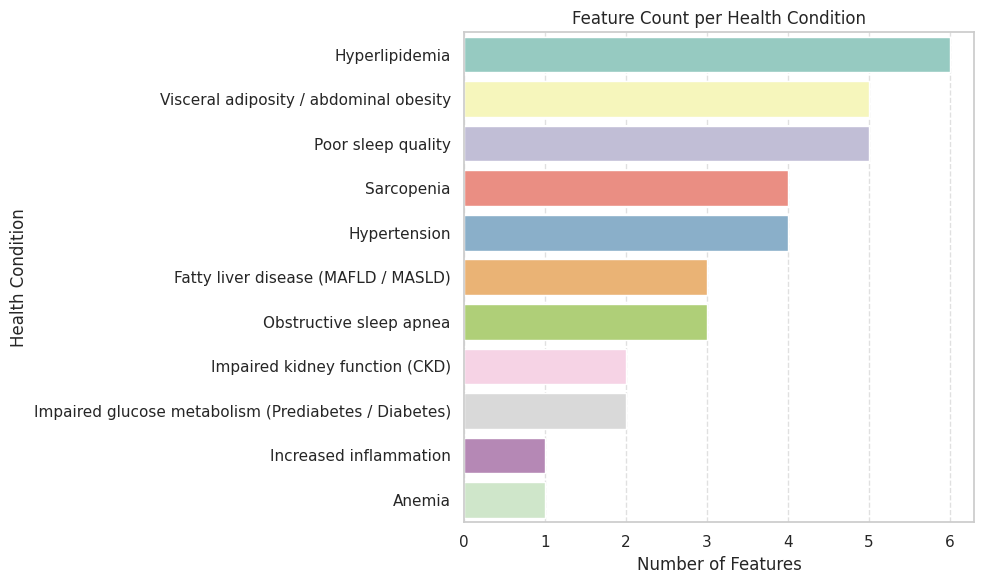

In [370]:
feature_condition_mapping = {
    'mean_hand_grip': 'Sarcopenia',
    'ALM': 'Sarcopenia',
    'ALMI': 'Sarcopenia',
    'ALM_BMI': 'Sarcopenia',
    'vat_fat_ratio': 'Visceral adiposity / abdominal obesity',
    'android/gynoid ratio': 'Visceral adiposity / abdominal obesity',
    'fat_mass_index': 'Visceral adiposity / abdominal obesity',
    'waist_hips_ratio': 'Visceral adiposity / abdominal obesity',
    'waist_height_ratio': 'Visceral adiposity / abdominal obesity',
    'sitting_systolic_bp_mean': 'Hypertension',
    'sitting_diastolic_bp_mean': 'Hypertension',
    'pulse_pressure': 'Hypertension',
    'mean_arterial_pressure': 'Hypertension',
    'liver_sound_speed_mps': 'Fatty liver disease (MAFLD / MASLD)',
    'AHI': 'Obstructive sleep apnea',
    'ODI': 'Obstructive sleep apnea',
    'RDI': 'Obstructive sleep apnea',
    '%DeepSleep': 'Poor sleep quality',
    'SleepLatency': 'Poor sleep quality',
    'NumberOfWakes': 'Poor sleep quality',
    'TotalSleepTime': 'Poor sleep quality',
    'TotalWakeTime': 'Poor sleep quality',
    'bt__egfr': 'Impaired kidney function (CKD)',
    'bt__urea': 'Impaired kidney function (CKD)',
    'bt__wbc': 'Increased inflammation',
    'bt__hba1c': 'Impaired glucose metabolism (Prediabetes / Diabetes)',
    'bt__glucose': 'Impaired glucose metabolism (Prediabetes / Diabetes)',
    'bt__alt_gpt': 'Fatty liver disease (MAFLD / MASLD)',
    'bt__ast_got': 'Fatty liver disease (MAFLD / MASLD)',
    'bt__mcv': 'Anemia',
    'bt__total_cholesterol': 'Hyperlipidemia',
    'bt__ldl_cholesterol': 'Hyperlipidemia',
    'bt__hdl_cholesterol': 'Hyperlipidemia',
    'bt__triglycerides': 'Hyperlipidemia',
    'bt__non_hdl_cholesterol': 'Hyperlipidemia',
    'triglyceride_to_hdl_ratio': 'Hyperlipidemia',
}

# Create DataFrame for plotting
df = pd.DataFrame.from_dict(feature_condition_mapping, orient='index', columns=['Condition'])
condition_counts = df['Condition'].value_counts().reset_index()
condition_counts.columns = ['Condition', 'Feature Count']

plt.figure(figsize=(10, 6))
sns.barplot(y='Condition', x='Feature Count', data=condition_counts, palette='Set3')
plt.title('Feature Count per Health Condition')
plt.xlabel('Number of Features')
plt.ylabel('Health Condition')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/feature_count_per_health_condition.png', dpi=300)

plt.show()

In [371]:
feature_condition_mapping = {
    # Visceral adiposity / abdominal obesity
    'vat_fat_ratio': 'Visceral adiposity / abdominal obesity',
    'android/gynoid ratio': 'Visceral adiposity / abdominal obesity',
    'fat_mass_index': 'Visceral adiposity / abdominal obesity',
    'waist_hips_ratio': 'Visceral adiposity / abdominal obesity',
    'waist_height_ratio': 'Visceral adiposity / abdominal obesity',
    'total_scan_vat_mass': 'Visceral adiposity / abdominal obesity',

    # Sarcopenia
    'mean_hand_grip': 'Sarcopenia',
    'ALM': 'Sarcopenia',
    'ALMI': 'Sarcopenia',
    'ALM_BMI': 'Sarcopenia',

    # Hypertension
    'sitting_systolic_bp_mean': 'Hypertension',
    'sitting_diastolic_bp_mean': 'Hypertension',
    'pulse_pressure': 'Hypertension',
    'mean_arterial_pressure': 'Hypertension',

    # Fatty liver disease (MAFLD / MASLD)
    'liver_sound_speed_mps': 'Fatty liver disease (MAFLD / MASLD)',

    # Obstructive sleep apnea
    'AHI': 'Obstructive sleep apnea',
    'ODI': 'Obstructive sleep apnea',
    'RDI': 'Obstructive sleep apnea',

    # Impaired kidney function (CKD)
    'bt__urea': 'Impaired kidney function (CKD)',
    'bt__uric_acid': 'Impaired kidney function (CKD)',

    # Increased inflammation
    'bt__wbc': 'Increased inflammation',

    # Impaired glucose metabolism (Prediabetes / Diabetes)
    'bt__glucose': 'Impaired glucose metabolism (Prediabetes / Diabetes)',

    # Anemia
    'bt__mcv': 'Anemia',
    'bt__hemoglobin': 'Anemia',

    # Hyperlipidemia
    'bt__total_cholesterol': 'Hyperlipidemia',
    'bt__triglycerides': 'Hyperlipidemia',
    'bt__non_hdl_cholesterol': 'Hyperlipidemia',
    'triglyceride_to_hdl_ratio': 'Hyperlipidemia',
    'bt__ldl_cholesterol': 'Hyperlipidemia',
    'bt__hdl_cholesterol': 'Hyperlipidemia',
}


# Convert to DataFrame (Condition -> Feature)
df = pd.DataFrame(
    [(cond, feat) for feat, cond in feature_condition_mapping.items()],
    columns=['Condition', 'Biomarkers']
).sort_values(by=['Condition', 'Biomarkers']).reset_index(drop=True)

# Format for Excel-style merged view (merge-like behavior)
df['Condition_display'] = df['Condition']
df.loc[df['Condition_display'].duplicated(), 'Condition_display'] = ''

# Reorder columns for final presentation
df_final = df[['Condition_display', 'Biomarkers']]
df_final.columns = ['Condition', 'Biomarkers']

# df_final.to_csv('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/feature_to_condition_mapping.csv')

In [372]:
bm_dexa_baseline = bm_dexa_baseline[['RegistrationCode', 'age', 'sex'] + dexa_targets + body_targets]
ultrasound_baseline = ultrasound_baseline[['RegistrationCode', 'age', 'sex'] + ultrasound_targets]
sleep_baseline = sleep_baseline[['RegistrationCode', 'age', 'sex'] + sleep_targets]

In [373]:
bm_dexa_baseline['RegistrationCode'].nunique() == 11916

False

In [374]:
ultrasound_baseline['RegistrationCode'].nunique() == 8485

False

In [375]:
sleep_baseline['RegistrationCode'].nunique() == 6803

False

In [376]:
blood_baseline['RegistrationCode'].nunique() == 7483

False

In [377]:
gut_bacteria_df['RegistrationCode'].nunique() == 10952

False

#### Merge bacteria from diet_mb

In [378]:
diet_mb = pd.read_pickle("/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/segal_species/diet_mb.pkl")

with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/segal_species/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features, diet_features, microbial_features = loaded_lists

diet_features = [f for f in diet_features if f not in base_features]

drop_maybe = ['Richness', 'Shannon_diversity', 'modified_HACK_top17_score', 'GMWI2_score']

microbial_features = diet_mb.drop(columns=diet_features + drop_maybe).reset_index()
(microbial_features, _) = rename_microbiome_columns(microbial_features, mb_names)
microbial_features.head()

,RegistrationCode,age,sex,Duodenibacillus intestinigallinarum,Duodenibacillus intestinavium,Duodenibacillus massiliensis,Sutterella wadsworthensis,Sutterella sp937923675,Sutterella seckii_A,Sutterella sp934255515,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,54.0,1.0,-4.0,-2.668341,-4.0,-4.000000,-3.139645,-1.72922,-4.0,...,-4.0,-2.963488,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.000000,-4.00000
1,10K_1001201093,42.0,0.0,-4.0,-4.000000,-4.0,-2.963934,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.0,-4.000000,-4.00000
2,10K_1002254441,45.0,1.0,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-3.228756,-4.0,-4.0,-4.0,-4.0,-2.383721,-4.00000
3,10K_1003113258,49.0,1.0,-4.0,-4.000000,-4.0,-2.651375,-4.000000,-4.00000,-4.0,...,-4.0,-3.561030,-4.000000,-3.622636,-4.0,-4.0,-4.0,-4.0,-3.806766,-4.00000
4,10K_1007330152,63.0,1.0,-4.0,-4.000000,-4.0,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-2.490747,-4.000000,-4.0,-4.0,-4.0,-4.0,-1.937423,-2.98186


In [379]:
len(diet_features)

698

In [380]:
diet_features

['Acorn squash',
 'Alfalfa sprouts',
 'Almond Beverage',
 'Almond flour',
 'Almond spread',
 'Almonds',
 'Amba',
 'Apple',
 'Apple Cake',
 'Apple Vinegar',
 'Apple juice',
 'Apricot',
 'Apropo',
 'Artichoke',
 'Arugula',
 'Asparagus',
 'Avocado',
 'Avocado Sandwich',
 'Bagel',
 'Baguette',
 'Baked apple',
 'Baklava',
 'Balsamic vinegar',
 'Bamba',
 'Banana',
 'Banana Cake',
 'Barbecue sauce',
 'Barley soup',
 'Basil',
 'Bean Noodles',
 'Bean soup',
 'Beans',
 'Beans black-eyed peas',
 'Beef',
 'Beef Cholent',
 'Beef Lasagna',
 'Beef Shawarma',
 'Beer',
 'Beet',
 'Beet Salad',
 'Berries',
 'Biscuit',
 'Bissli',
 'Black beans',
 'Blintzes',
 'Blue Cheese',
 'Blueberries',
 'Boiled corn',
 'Bolognese',
 'Bounty',
 'Brazil nuts',
 'Bread',
 'Bread Crumbs',
 'Brioche',
 'Broccoli',
 'Broth',
 'Brown Rice',
 'Brown Sugar',
 'Brownies',
 'Buckwheat Bread',
 'Buckwheat crackers',
 'Bulgur',
 'Burekas',
 'Butter',
 'Butter Cookies',
 'Caesar Salad',
 'Cake',
 'Calamari',
 'Camembert or Brie',
 

In [381]:
microbial_features

,RegistrationCode,age,sex,Duodenibacillus intestinigallinarum,Duodenibacillus intestinavium,Duodenibacillus massiliensis,Sutterella wadsworthensis,Sutterella sp937923675,Sutterella seckii_A,Sutterella sp934255515,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,54.0,1.0,-4.000000,-2.668341,-4.000000,-4.000000,-3.139645,-1.72922,-4.0,...,-4.0,-2.963488,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000
1,10K_1001201093,42.0,0.0,-4.000000,-4.000000,-4.000000,-2.963934,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000
2,10K_1002254441,45.0,1.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-3.228756,-4.0,-4.0,-4.0,-4.000000,-2.383721,-4.00000
3,10K_1003113258,49.0,1.0,-4.000000,-4.000000,-4.000000,-2.651375,-4.000000,-4.00000,-4.0,...,-4.0,-3.561030,-4.000000,-3.622636,-4.0,-4.0,-4.0,-4.000000,-3.806766,-4.00000
4,10K_1007330152,63.0,1.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-2.490747,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.937423,-2.98186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_9996884777,53.0,0.0,-4.000000,-4.000000,-4.000000,-2.700604,-4.000000,-4.00000,-4.0,...,-4.0,-3.536561,-3.195601,-3.350185,-4.0,-4.0,-4.0,-4.000000,-3.832439,-3.78628
10064,10K_9998420917,47.0,0.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-2.785597,-3.309716,-4.0,-4.0,-4.0,-2.564519,-2.439687,-4.00000
10065,10K_9998635752,60.0,1.0,-4.000000,-4.000000,-4.000000,-1.773531,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.996193,-4.00000
10066,10K_9999226141,41.0,1.0,-3.831234,-4.000000,-1.781562,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-3.461156,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000


In [382]:
microbial_features

,RegistrationCode,age,sex,Duodenibacillus intestinigallinarum,Duodenibacillus intestinavium,Duodenibacillus massiliensis,Sutterella wadsworthensis,Sutterella sp937923675,Sutterella seckii_A,Sutterella sp934255515,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,54.0,1.0,-4.000000,-2.668341,-4.000000,-4.000000,-3.139645,-1.72922,-4.0,...,-4.0,-2.963488,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000
1,10K_1001201093,42.0,0.0,-4.000000,-4.000000,-4.000000,-2.963934,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000
2,10K_1002254441,45.0,1.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-3.228756,-4.0,-4.0,-4.0,-4.000000,-2.383721,-4.00000
3,10K_1003113258,49.0,1.0,-4.000000,-4.000000,-4.000000,-2.651375,-4.000000,-4.00000,-4.0,...,-4.0,-3.561030,-4.000000,-3.622636,-4.0,-4.0,-4.0,-4.000000,-3.806766,-4.00000
4,10K_1007330152,63.0,1.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-2.490747,-4.000000,-4.0,-4.0,-4.0,-4.000000,-1.937423,-2.98186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_9996884777,53.0,0.0,-4.000000,-4.000000,-4.000000,-2.700604,-4.000000,-4.00000,-4.0,...,-4.0,-3.536561,-3.195601,-3.350185,-4.0,-4.0,-4.0,-4.000000,-3.832439,-3.78628
10064,10K_9998420917,47.0,0.0,-4.000000,-4.000000,-4.000000,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-2.785597,-3.309716,-4.0,-4.0,-4.0,-2.564519,-2.439687,-4.00000
10065,10K_9998635752,60.0,1.0,-4.000000,-4.000000,-4.000000,-1.773531,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.0,-4.000000,-2.996193,-4.00000
10066,10K_9999226141,41.0,1.0,-3.831234,-4.000000,-1.781562,-4.000000,-4.000000,-4.00000,-4.0,...,-4.0,-4.000000,-4.000000,-3.461156,-4.0,-4.0,-4.0,-4.000000,-4.000000,-4.00000


In [383]:
bm_dexa_baseline['RegistrationCode'].nunique() == 11916

False

In [384]:
bm_dexa_baseline

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,body_comp_trunk_fat_mass,body_comp_trunk_tissue_percent_fat,body_comp_android_tissue_percent_fat,body_comp_total_fat_free_mass,body_comp_legs_fat_free_mass,body_comp_gynoid_tissue_percent_fat,spine_l1_l4_bmd,femur_left_neck_bmd,bmi,neck_circumference
0,10K_1000942861,54.0,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,13.371301,30.841303,33.474897,67.413707,23.062210,25.556870,1.245242,1.060365,28.176579,NaN
1,10K_1001201093,42.0,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,7.697050,28.042318,27.167414,41.644055,13.740875,37.003332,NaN,1.047920,20.553633,NaN
2,10K_1002033709,43.0,0.0,0.035183,1.193083,0.006507,0.879121,0.503145,57.500000,0.016507,...,9.150326,33.888919,35.021937,39.170940,13.035767,29.354154,1.173749,0.795180,21.755468,34.0
3,10K_1002087123,42.0,0.0,NaN,NaN,NaN,0.949580,0.665489,60.950001,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.660603,NaN
4,10K_1002254441,45.0,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,13.069000,35.900000,39.700000,51.921000,17.246000,33.800000,1.193000,0.991118,23.355637,35.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12032,10K_9476463140,46.0,0.0,0.009860,0.665827,NaN,NaN,NaN,NaN,0.015260,...,6.420807,27.143848,24.386837,38.045425,12.694473,36.626361,1.205696,0.899751,NaN,NaN
12033,10K_3096982135,64.0,0.0,0.026168,0.845633,NaN,NaN,NaN,NaN,0.015710,...,11.107196,38.978962,40.854411,38.156650,12.611766,48.312215,1.100067,0.799480,NaN,NaN
12034,10K_6945742713,49.0,1.0,0.058928,1.612187,NaN,NaN,NaN,NaN,0.023699,...,8.539250,24.920915,26.596741,55.539309,18.487535,16.497305,NaN,NaN,NaN,NaN
12035,10K_1640388450,44.0,0.0,7.010344,0.645227,NaN,NaN,NaN,NaN,0.014645,...,5.830354,25.069171,22.107401,37.103993,11.983816,34.262955,1.169931,0.977680,NaN,NaN


In [385]:
ultrasound_baseline['RegistrationCode'].nunique() == 8485

False

In [386]:
ultrasound_baseline

,RegistrationCode,age,sex,liver_sound_speed_mps
0,10K_1007330152,63.0,1.0,1520.0
1,10K_1048446667,40.0,1.0,1580.0
2,10K_1157047250,52.0,0.0,1500.0
3,10K_1061361661,53.0,0.0,1570.0
4,10K_1093965066,55.0,0.0,1500.0
...,...,...,...,...
19160,10K_3188466583,41.0,1.0,1640.0
19172,10K_8523313991,50.0,1.0,1640.0
19189,10K_9774784763,42.0,1.0,1590.0
19191,10K_2390885899,40.0,1.0,1580.0


In [387]:
sleep_baseline['RegistrationCode'].nunique() == 6803

False

In [388]:
sleep_baseline

,RegistrationCode,age,sex,AHI,ODI,RDI
0,10K_1000942861,54.0,1.0,17.575000,6.870000,25.930000
1,10K_1001201093,21.0,0.0,0.930000,0.183333,11.483333
2,10K_1002033709,43.0,0.0,3.696000,1.110000,14.128000
3,10K_1002254441,45.0,1.0,5.503333,2.330000,10.346667
4,10K_1003113258,49.0,1.0,1.920000,0.520000,6.820000
...,...,...,...,...,...,...
6801,10K_9994795317,47.0,1.0,15.116667,10.683333,19.480000
6802,10K_9995623290,54.0,1.0,5.113333,2.566667,12.683333
6803,10K_9995823183,47.0,1.0,4.516667,0.370000,23.946667
6804,10K_9996884777,53.0,0.0,NaN,NaN,NaN


In [389]:
blood_baseline['RegistrationCode'].nunique() == 7483

False

In [390]:
blood_baseline

,RegistrationCode,age,sex,bt__urea,bt__wbc,bt__glucose,bt__mcv,bt__hemoglobin,bt__uric_acid,bt__total_cholesterol,...,bt__esr,bt__alt_gpt,bt__ast_got,bt__gamma_gt,bt__ckd_epi,urine__albumin_creatinine_ratio,urine__microalbumin,bt__vitamin_d,bt__ferritin,bt__fibrinogen_calcu
0,10K_1289780556,67.0,0.0,NaN,6.27,NaN,87.6,14.91,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10K_4247991463,55.0,1.0,NaN,4.21,NaN,85.7,15.65,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10K_2552721016,40.0,1.0,NaN,4.27,NaN,90.7,16.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10K_8058304378,53.0,1.0,NaN,6.10,NaN,95.9,14.66,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10K_3742861225,40.0,0.0,NaN,5.68,NaN,81.3,12.49,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7490,10K_2402879566,49.0,0.0,NaN,5.20,NaN,96.0,12.10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN
7491,10K_7380554963,48.0,1.0,26.1,NaN,96.0,NaN,NaN,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7492,10K_3805999432,62.0,1.0,NaN,7.20,NaN,83.8,13.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8.39,18.64,20.44,NaN,NaN
7493,10K_8520488580,62.0,0.0,25.0,5.10,95.0,88.0,12.90,NaN,238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Merge all loaders into a master data frame

In [391]:
bm_dexa_baseline = bm_dexa_baseline.drop(columns=['age', 'sex'])
ultrasound_baseline = ultrasound_baseline.drop(columns=['age', 'sex'])
sleep_baseline = sleep_baseline.drop(columns=['age', 'sex'])
blood_baseline = blood_baseline.drop(columns=['age', 'sex'])

In [392]:
phenotypes_mb = (
    bm_dexa_baseline
    .merge(blood_baseline, on=['RegistrationCode'], how='outer')
    .merge(ultrasound_baseline, on=['RegistrationCode'], how='outer')
    .merge(sleep_baseline, on=['RegistrationCode'], how='outer')
)
phenotypes_mb

,RegistrationCode,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,ALMI,ALM_BMI,...,bt__ckd_epi,urine__albumin_creatinine_ratio,urine__microalbumin,bt__vitamin_d,bt__ferritin,bt__fibrinogen_calcu,liver_sound_speed_mps,AHI,ODI,RDI
0,10K_1000942861,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,0.009441,0.000335,...,NaN,NaN,NaN,NaN,NaN,NaN,1550.0,17.575000,6.870000,25.930000
1,10K_1001201093,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,0.005900,0.000287,...,NaN,NaN,NaN,NaN,NaN,NaN,1550.0,0.930000,0.183333,11.483333
2,10K_1002033709,0.035183,1.193083,0.006507,0.879121,0.503145,57.500000,0.016507,0.006530,0.000300,...,NaN,NaN,NaN,NaN,NaN,NaN,1550.0,3.696000,1.110000,14.128000
3,10K_1002087123,NaN,NaN,NaN,0.949580,0.665489,60.950001,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10K_1002254441,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,0.006890,0.000295,...,NaN,NaN,NaN,NaN,NaN,NaN,1570.0,5.503333,2.330000,10.346667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11983,10K_6945742713,0.058928,1.612187,NaN,NaN,NaN,NaN,0.023699,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1570.0,NaN,NaN,NaN
11984,10K_1640388450,7.010344,0.645227,NaN,NaN,NaN,NaN,0.014645,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.150000,1.135000,4.605000
11985,10K_1599538935,0.019868,0.917324,NaN,NaN,NaN,NaN,0.020483,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11986,10K_3398498395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1600.0,NaN,NaN,NaN


In [393]:
# 2. Merge — keep age/sex from microbial_features
phenotypes_mb = pd.merge(
    phenotypes_mb,
    microbial_features,
    on='RegistrationCode',
    how='inner'
)

cols = ['RegistrationCode', 'age', 'sex'] + [col for col in phenotypes_mb.columns if col not in ['RegistrationCode', 'age', 'sex']]
phenotypes_mb = phenotypes_mb[cols]

phenotypes_mb

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,54.0,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,-4.0,-2.963488,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,-4.000000
1,10K_1001201093,42.0,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,-4.000000
2,10K_1002254441,45.0,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,-4.0,-4.000000,-4.000000,-3.228756,-4.0,-4.0,-4.000000,-4.000000,-2.383721,-4.000000
3,10K_1003113258,49.0,1.0,NaN,NaN,NaN,0.481481,0.268041,102.850002,NaN,...,-4.0,-3.561030,-4.000000,-3.622636,-4.0,-4.0,-4.000000,-4.000000,-3.806766,-4.000000
4,10K_1007330152,63.0,1.0,0.095797,1.595805,0.014307,1.035714,0.713846,97.450001,0.025144,...,-4.0,-4.000000,-2.490747,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-1.937423,-2.981860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,51.0,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,-4.0,-2.715262,-3.165483,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-3.425893,-4.000000
10064,10K_4637431621,57.0,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-4.000000,-4.000000,-4.000000
10065,10K_9999226141,41.0,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,-4.0,-4.000000,-4.000000,-3.461156,-4.0,-4.0,-4.000000,-4.000000,-4.000000,-4.000000
10066,10K_4721223871,55.0,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,-4.0,-4.000000,-4.000000,-4.000000,-4.0,-4.0,-4.000000,-3.377804,-4.000000,-3.699444


Microbial Feature Standardization

In [394]:
# Drop samples with missing demographic values
phenotypes_mb = phenotypes_mb.dropna(subset=['age', 'sex'])

# Select microbial features only
exclude = {'age', 'sex', 'RegistrationCode'}
features_to_standardize = [f for f in microbial_features.columns if f not in exclude]
age_feature = ['age']

# Standardize selected features

home_path = '/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/'
SPECIES = 'segal_species' # 'segal_species' or 'segal_species'

with open(home_path + f'data/{SPECIES}/mb_scaler.pkl', 'rb') as scaler_file:
        mb_scaler = pickle.load(scaler_file)
with open(home_path + f'data/{SPECIES}/age_scaler.pkl', 'rb') as scaler_file:
        age_scaler = pickle.load(scaler_file)

phenotypes_mb[features_to_standardize] = mb_scaler.transform(
    phenotypes_mb[features_to_standardize]
)
phenotypes_mb[age_feature] = age_scaler.transform(
    phenotypes_mb[age_feature]
)

# Display standardized features
phenotypes_mb[features_to_standardize]

/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator StandardScaler from version 0.23.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"
/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


,Duodenibacillus intestinigallinarum,Duodenibacillus intestinavium,Duodenibacillus massiliensis,Sutterella wadsworthensis,Sutterella sp937923675,Sutterella seckii_A,Sutterella sp934255515,Sutterella wadsworthensis_A,Akkermansia muciniphila_A,Akkermansia muciniphila,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,-0.254961,3.120391,-0.487390,-1.007000,3.406513,4.629818,-0.445961,-0.641493,-0.367836,0.413829,...,-0.241241,1.002121,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
1,-0.254961,-0.255589,-0.487390,0.171767,-0.318362,-0.359678,-0.445961,1.863654,-0.367836,1.665683,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
2,-0.254961,-0.255589,-0.487390,-1.007000,-0.318362,-0.359678,-0.445961,-0.641493,-0.367836,1.517420,...,-0.241241,-0.713026,-0.557742,0.993315,-0.311122,-0.245562,-0.237235,-0.273951,1.692586,-0.412616
3,-0.254961,-0.255589,-0.487390,0.527377,-0.318362,-0.359678,-0.445961,-0.641493,-0.367836,1.499355,...,-0.241241,0.013351,-0.557742,0.079387,-0.311122,-0.245562,-0.237235,-0.273951,-0.494680,-0.412616
4,-0.254961,-0.255589,-0.487390,-1.007000,-0.318362,-0.359678,-0.445961,-0.641493,2.248167,0.531414,...,-0.241241,-0.713026,1.727326,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,2.378561,1.526925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,-0.254961,-0.255589,-0.487390,1.076060,-0.318362,-0.359678,-0.445961,2.026564,-0.367836,-0.939106,...,-0.241241,1.412868,0.705749,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,0.090735,-0.412616
10064,-0.254961,-0.255589,0.976881,-0.894677,4.537632,2.439784,1.940842,0.396958,-0.367836,-0.939106,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10065,0.172381,-0.255589,2.386357,-1.007000,-0.318362,-0.359678,-0.445961,-0.641493,-0.367836,-0.939106,...,-0.241241,-0.713026,-0.557742,0.454073,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10066,6.093827,-0.255589,-0.487390,-1.007000,-0.318362,-0.359678,-0.445961,-0.641493,-0.367836,-0.939106,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,1.317316,-0.791686,0.159939


In [395]:
phenotypes_mb

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,0.376406,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,-0.241241,1.002121,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
1,10K_1001201093,-1.188551,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
2,10K_1002254441,-0.797312,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,-0.241241,-0.713026,-0.557742,0.993315,-0.311122,-0.245562,-0.237235,-0.273951,1.692586,-0.412616
3,10K_1003113258,-0.275660,1.0,NaN,NaN,NaN,0.481481,0.268041,102.850002,NaN,...,-0.241241,0.013351,-0.557742,0.079387,-0.311122,-0.245562,-0.237235,-0.273951,-0.494680,-0.412616
4,10K_1007330152,1.550124,1.0,0.095797,1.595805,0.014307,1.035714,0.713846,97.450001,0.025144,...,-0.241241,-0.713026,1.727326,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,2.378561,1.526925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,-0.014834,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,-0.241241,1.412868,0.705749,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,0.090735,-0.412616
10064,10K_4637431621,0.767645,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10065,10K_9999226141,-1.318965,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,-0.241241,-0.713026,-0.557742,0.454073,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10066,10K_4721223871,0.506819,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,1.317316,-0.791686,0.159939


Replace outliers with NA

In [396]:
def replace_outliers_with_nan_iqr(df, target_cols, k=1.5):
    df_copy = df.copy()
    for col in target_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR
        # Replace outliers with NaN
        df_copy.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = np.nan
    return df_copy

phenotypes_mb = replace_outliers_with_nan_iqr(phenotypes_mb, target_phenotypes)

phenotypes_mb

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Alistipes avistercoris,Alistipes dispar,Tidjanibacter inops,Oxalobacter aliiformigenes,Oxalobacter formigenes,Duodenibacillus sp900544335,Aphodousia faecalis,Parasutterella gallistercoris,Parasutterella excrementihominis,Mesosutterella multiformis
0,10K_1000942861,0.376406,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,-0.241241,1.002121,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
1,10K_1001201093,-1.188551,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
2,10K_1002254441,-0.797312,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,-0.241241,-0.713026,-0.557742,0.993315,-0.311122,-0.245562,-0.237235,-0.273951,1.692586,-0.412616
3,10K_1003113258,-0.275660,1.0,NaN,NaN,NaN,NaN,NaN,102.850002,NaN,...,-0.241241,0.013351,-0.557742,0.079387,-0.311122,-0.245562,-0.237235,-0.273951,-0.494680,-0.412616
4,10K_1007330152,1.550124,1.0,0.095797,1.595805,0.014307,1.035714,NaN,97.450001,0.025144,...,-0.241241,-0.713026,1.727326,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,2.378561,1.526925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,-0.014834,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,-0.241241,1.412868,0.705749,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,0.090735,-0.412616
10064,10K_4637431621,0.767645,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10065,10K_9999226141,-1.318965,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,-0.241241,-0.713026,-0.557742,0.454073,-0.311122,-0.245562,-0.237235,-0.273951,-0.791686,-0.412616
10066,10K_4721223871,0.506819,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,-0.241241,-0.713026,-0.557742,-0.796220,-0.311122,-0.245562,-0.237235,1.317316,-0.791686,0.159939


In [397]:
mb_names[mb_names['species_new'] == 'Faecalibacterium longum']

,Unnamed: 0,kingdom,phylum,class,order,family,genus,species,sBin,gBin,...,gSGB,fSGB,kingdom_new,phylum_new,class_new,order_new,family_new,genus_new,species_new,Daniel_Species
fBin__534|gBin__2021|sBin__3065,Rep_3065,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii_G,3065.0,2021.0,...,9740,3058,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Ruminococcaceae,Faecalibacterium,Faecalibacterium longum,Faecalibacterium longum
fBin__534|gBin__2021|sBin__3066,Rep_3066,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii_G,3066.0,2021.0,...,9740,3058,Bacteria,Bacillota_A,Clostridia,Oscillospirales,Ruminococcaceae,Faecalibacterium,Faecalibacterium longum,Faecalibacterium longum_1


In [398]:
"Alistipescatomonas sp900066785" in phenotypes_mb.columns

False

In [399]:
"Alistipescatomonas sp900066785" in microbial_features.columns

False

Save the data frame

In [400]:
phenotypes_mb.to_pickle(path='/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/phenotypes_mb_new_check.pkl')

#### Merge diet to predict phenotypes

In [401]:
diet_mb = pd.read_pickle("/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/segal_species/diet_mb.pkl")

with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/segal_species/my_lists.pkl', 'rb') as file:
    loaded_lists = pickle.load(file)
base_features, diet_features, microbial_features = loaded_lists

diet_features_df = diet_mb[diet_features].reset_index()
diet_features_df

,RegistrationCode,Acorn squash,Alfalfa sprouts,Almond Beverage,Almond flour,Almond spread,Almonds,Amba,Apple,Apple Cake,...,Spicesandherbs,Vegetables,bakedgoods,fruitjuicesandsoftdrinks,milkcreamcheeseandyogurts,sweetmilkproducts,sweets,age,sex,Energy / BMR
0,10K_1000942861,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.016416,0.000000,...,0.000000,0.045932,0.000000,0.000000,0.006411,0.000000,0.178383,54.0,1.0,0.882186
1,10K_1001201093,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013895,0.000000,...,0.000000,0.089702,0.000000,0.022094,0.036706,0.029071,0.296512,42.0,0.0,1.044537
2,10K_1002254441,0.0,0.0,0.0,0.0,0.0,0.081238,0.0,0.000000,0.000000,...,0.000000,0.209010,0.000000,0.000000,0.000656,0.000000,0.002445,45.0,1.0,1.133905
3,10K_1003113258,0.0,0.0,0.0,0.0,0.0,0.002048,0.0,0.008929,0.000000,...,0.000000,0.045934,0.004363,0.010416,0.046349,0.000000,0.101867,49.0,1.0,0.791438
4,10K_1007330152,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.041334,0.089115,0.032551,0.048597,0.000000,0.214221,63.0,1.0,0.875754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_9996884777,0.0,0.0,0.0,0.0,0.0,0.002401,0.0,0.000000,0.000000,...,0.000000,0.230306,0.011906,0.014559,0.000000,0.000000,0.143853,53.0,0.0,0.868283
10064,10K_9998420917,0.0,0.0,0.0,0.0,0.0,0.019995,0.0,0.018783,0.000000,...,0.000568,0.120191,0.000000,0.000000,0.024279,0.000000,0.061852,47.0,0.0,1.091929
10065,10K_9998635752,0.0,0.0,0.0,0.0,0.0,0.001607,0.0,0.011305,0.000000,...,0.000000,0.093734,0.000000,0.000000,0.061951,0.000000,0.024665,60.0,1.0,0.781005
10066,10K_9999226141,0.0,0.0,0.0,0.0,0.0,0.003292,0.0,0.000000,0.000000,...,0.000000,0.014000,0.026904,0.008415,0.004299,0.000000,0.152223,41.0,1.0,1.531901


In [402]:
phenotypes_diet = (
    bm_dexa_baseline
    .merge(ultrasound_baseline, on=['RegistrationCode'], how='outer')
    .merge(sleep_baseline, on=['RegistrationCode'], how='outer')
    .merge(blood_baseline, on=['RegistrationCode'], how='outer')
)

# 2. Merge — keep age/sex from diet_features
phenotypes_diet  = pd.merge(
    phenotypes_diet ,
    diet_features_df,
    on='RegistrationCode',
    how='inner'
)

cols = ['RegistrationCode', 'age', 'sex'] + [col for col in phenotypes_diet.columns if col not in ['RegistrationCode', 'age', 'sex']]
phenotypes_diet = phenotypes_diet[cols]

# Drop samples with missing demographic values
phenotypes_diet = phenotypes_diet.dropna(subset=['age', 'sex'])

# Select microbial features only
exclude = {'age', 'sex', 'RegistrationCode'}
features_to_standardize = [f for f in diet_features_df.columns if f not in exclude]

with open(home_path + f'data/{SPECIES}/diet_scaler.pkl', 'rb') as scaler_file:
        diet_scaler = pickle.load(scaler_file)
with open(home_path + f'data/{SPECIES}/age_scaler.pkl', 'rb') as scaler_file:
        age_scaler = pickle.load(scaler_file)

# Standardize selected features
 
phenotypes_diet[features_to_standardize] = diet_scaler.transform(
    phenotypes_diet[features_to_standardize]
)
phenotypes_diet[age_feature] = age_scaler.transform(
    phenotypes_diet[age_feature]
)

# Display standardized features
phenotypes_diet[features_to_standardize]

phenotypes_diet

/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator StandardScaler from version 0.23.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,
/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"
/home/barakdan/.local/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Snacks,Soupsandsauces,Spicesandherbs,Vegetables,bakedgoods,fruitjuicesandsoftdrinks,milkcreamcheeseandyogurts,sweetmilkproducts,sweets,Energy / BMR
0,10K_1000942861,0.376406,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,-0.446606,-0.524400,-0.212046,-0.622546,-0.400484,-0.461391,-0.853125,-0.307813,0.862471,-0.707407
1,10K_1001201093,-1.188551,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,-0.446606,-0.524400,-0.212046,0.266801,-0.400484,0.797470,-0.168680,1.905701,2.388874,-0.084558
2,10K_1002254441,-0.797312,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,-0.446606,1.355281,-0.212046,2.691021,-0.400484,-0.461391,-0.983138,-0.307813,-1.410910,0.258295
3,10K_1003113258,-0.275660,1.0,NaN,NaN,NaN,0.481481,0.268041,102.850002,NaN,...,-0.446606,-0.524400,-0.212046,-0.622523,-0.191647,0.132093,0.049181,-0.307813,-0.126235,-1.055558
4,10K_1007330152,1.550124,1.0,0.095797,1.595805,0.014307,1.035714,0.713846,97.450001,0.025144,...,-0.446606,0.232297,-0.212046,-0.715983,3.865357,1.393265,0.099974,-0.307813,1.325552,-0.732085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,-0.014834,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,0.047799,-0.375269,0.309261,0.679008,-0.400484,-0.308386,0.996314,0.119327,-0.448789,1.702312
10064,10K_4637431621,0.767645,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,-0.446606,-0.512674,-0.212046,0.207226,-0.400484,-0.461391,-0.734366,-0.307813,-0.922974,-0.044615
10065,10K_9999226141,-1.318965,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,-0.446606,3.389876,-0.212046,-1.271383,0.887380,0.018056,-0.900835,-0.307813,0.524448,1.785178
10066,10K_4721223871,0.506819,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,2.931116,-0.524400,0.408211,0.352502,2.056562,-0.461391,0.283545,-0.307813,-1.136760,0.029163


In [403]:
phenotypes_diet.to_pickle(path='/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/phenotypes_diet_new.pkl')

Create Master Data Frame (Base + Diet + Microbiome + Phenotypes) 

In [404]:
phenotypes_diet_microbiome = pd.merge(left=phenotypes_mb, right=phenotypes_diet, on='RegistrationCode', how='inner')

In [405]:
diet_features_df.drop(columns=['age', 'sex'], inplace=True)

In [406]:
phenotypes_diet_microbiome = pd.merge(phenotypes_mb, diet_features_df, on='RegistrationCode', how='inner')
phenotypes_diet_microbiome

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Snacks,Soupsandsauces,Spicesandherbs,Vegetables,bakedgoods,fruitjuicesandsoftdrinks,milkcreamcheeseandyogurts,sweetmilkproducts,sweets,Energy / BMR
0,10K_1000942861,0.376406,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,0.000000,0.000000,0.000000,0.045932,0.000000,0.000000,0.006411,0.000000,0.178383,0.882186
1,10K_1001201093,-1.188551,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,0.000000,0.000000,0.000000,0.089702,0.000000,0.022094,0.036706,0.029071,0.296512,1.044537
2,10K_1002254441,-0.797312,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,0.000000,0.018351,0.000000,0.209010,0.000000,0.000000,0.000656,0.000000,0.002445,1.133905
3,10K_1003113258,-0.275660,1.0,NaN,NaN,NaN,NaN,NaN,102.850002,NaN,...,0.000000,0.000000,0.000000,0.045934,0.004363,0.010416,0.046349,0.000000,0.101867,0.791438
4,10K_1007330152,1.550124,1.0,0.095797,1.595805,0.014307,1.035714,NaN,97.450001,0.025144,...,0.000000,0.007387,0.000000,0.041334,0.089115,0.032551,0.048597,0.000000,0.214221,0.875754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,-0.014834,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,0.009313,0.001456,0.001186,0.109988,0.000000,0.002685,0.088271,0.005610,0.076904,1.510301
10064,10K_4637431621,0.767645,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,0.000000,0.000114,0.000000,0.086770,0.000000,0.000000,0.011667,0.000000,0.040207,1.054949
10065,10K_9999226141,-1.318965,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,0.000000,0.038214,0.000000,0.014000,0.026904,0.008415,0.004299,0.000000,0.152223,1.531901
10066,10K_4721223871,0.506819,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,0.063627,0.000000,0.001412,0.093919,0.051329,0.000000,0.056722,0.000000,0.023662,1.074180


In [407]:
phenotypes_diet_microbiome.to_pickle(path='/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/phenotypes_diet_microbiome_new_study_ids.pkl')

In [408]:
for col in ['age', 'sex']:
    if col in diet_features:
        diet_features.remove(col)

In [409]:
base_features = ['age', 'sex', ]  #### Add BMI here when ready

# microbial_features 
microbial_features = [
    col for col in phenotypes_diet_microbiome.columns
    if col not in target_phenotypes + ['RegistrationCode'] + base_features + diet_features
]

# Now save everything together as ONE tuple
all_features = (base_features, diet_features, target_phenotypes, microbial_features)

with open('/net/mraid20/export/genie/LabData/Analyses/tomerse/diet_mb/data/my_lists_new_study_ids.pkl', 'wb') as f:
    pickle.dump(all_features, f)

In [410]:
phenotypes_diet_microbiome

,RegistrationCode,age,sex,vat_fat_ratio,android/gynoid ratio,fat_mass_index,waist_hips_ratio,waist_height_ratio,mean_hand_grip,ALM,...,Snacks,Soupsandsauces,Spicesandherbs,Vegetables,bakedgoods,fruitjuicesandsoftdrinks,milkcreamcheeseandyogurts,sweetmilkproducts,sweets,Energy / BMR
0,10K_1000942861,0.376406,1.0,0.056535,1.309820,0.007463,0.925234,0.548476,131.349998,0.030759,...,0.000000,0.000000,0.000000,0.045932,0.000000,0.000000,0.006411,0.000000,0.178383,0.882186
1,10K_1001201093,-1.188551,0.0,0.021434,0.734188,0.006269,0.783505,0.447059,67.349998,0.017051,...,0.000000,0.000000,0.000000,0.089702,0.000000,0.022094,0.036706,0.029071,0.296512,1.044537
2,10K_1002254441,-0.797312,1.0,0.055767,1.174556,0.006893,0.947368,0.505618,86.250000,0.021831,...,0.000000,0.018351,0.000000,0.209010,0.000000,0.000000,0.000656,0.000000,0.002445,1.133905
3,10K_1003113258,-0.275660,1.0,NaN,NaN,NaN,NaN,NaN,102.850002,NaN,...,0.000000,0.000000,0.000000,0.045934,0.004363,0.010416,0.046349,0.000000,0.101867,0.791438
4,10K_1007330152,1.550124,1.0,0.095797,1.595805,0.014307,1.035714,NaN,97.450001,0.025144,...,0.000000,0.007387,0.000000,0.041334,0.089115,0.032551,0.048597,0.000000,0.214221,0.875754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,10K_1439720299,-0.014834,1.0,0.041723,1.154418,NaN,NaN,NaN,NaN,0.022372,...,0.009313,0.001456,0.001186,0.109988,0.000000,0.002685,0.088271,0.005610,0.076904,1.510301
10064,10K_4637431621,0.767645,0.0,0.037967,0.913265,NaN,NaN,NaN,NaN,0.015591,...,0.000000,0.000114,0.000000,0.086770,0.000000,0.000000,0.011667,0.000000,0.040207,1.054949
10065,10K_9999226141,-1.318965,1.0,0.052698,1.429954,NaN,NaN,NaN,NaN,0.024904,...,0.000000,0.038214,0.000000,0.014000,0.026904,0.008415,0.004299,0.000000,0.152223,1.531901
10066,10K_4721223871,0.506819,0.0,0.038641,1.035379,NaN,NaN,NaN,NaN,0.017069,...,0.063627,0.000000,0.001412,0.093919,0.051329,0.000000,0.056722,0.000000,0.023662,1.074180


In [411]:
target_phenotypes

['bmi',
 'neck_circumference',
 'vat_fat_ratio',
 'android/gynoid ratio',
 'fat_mass_index',
 'waist_hips_ratio',
 'waist_height_ratio',
 'mean_hand_grip',
 'ALM',
 'ALMI',
 'ALM_BMI',
 'sitting_systolic_bp_mean',
 'sitting_diastolic_bp_mean',
 'pulse_pressure',
 'mean_arterial_pressure',
 'total_scan_vat_mass',
 'body_comp_trunk_fat_mass',
 'body_comp_trunk_tissue_percent_fat',
 'body_comp_android_tissue_percent_fat',
 'body_comp_total_fat_free_mass',
 'body_comp_legs_fat_free_mass',
 'body_comp_gynoid_tissue_percent_fat',
 'spine_l1_l4_bmd',
 'femur_left_neck_bmd',
 'bt__urea',
 'bt__wbc',
 'bt__glucose',
 'bt__mcv',
 'bt__hemoglobin',
 'bt__uric_acid',
 'bt__total_cholesterol',
 'bt__triglycerides',
 'bt__non_hdl_cholesterol',
 'triglyceride_to_hdl_ratio',
 'bt__ldl_cholesterol',
 'bt__hdl_cholesterol',
 'bt__hba1c',
 'bt__ogtt_2h',
 'bt__ogtt_1h',
 'bt__gtt',
 'bt__insulin',
 'bt__fructosamine',
 'bt__crp_hs',
 'bt__esr',
 'bt__alt_gpt',
 'bt__ast_got',
 'bt__gamma_gt',
 'bt__ckd_e